<a href="https://colab.research.google.com/github/202204417/25-2-DIP-202204417/blob/main/HW_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python -m pip install pyradiomics


In [ ]:
import radiomics
from radiomics import featureextractor
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
import numpy as np

In [ ]:
## 1. Code sell
settings = {}
settings['binWidth'] = 20
settings['sigma'] = [1]
settings['normalize']=True
settings['geometryTolerance']=1

extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('shape')
extractor.enableFeatureClassByName('glcm')

print('Extraction parameters set successfully.')

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Applying custom setting overrides: {'binWidth': 20, 'sigma': [1], 'normalize': True, 'geometryTolerance': 1}


Extraction parameters set successfully.


In [ ]:
def load_and_extract(img_path, mask_path, label):
    print(f"[{label}] Extracting features...")
    image = sitk.ReadImage(img_path)
    mask = sitk.ReadImage(mask_path)
    return extractor.execute(image, mask)

In [ ]:
try:
    # High-grade glioma
    features_h = load_and_extract('H_t1ce.nii.gz', 'H_seg.nii.gz', 'High-Grade')
    # Low-grade glioma
    features_l = load_and_extract('L_t1ce.nii.gz', 'L_seg.nii.gz', 'Low-Grade')
except Exception as e:
    print(f"오류 발생: {e}")
    print("파일이 업로드되었는지 확인해주세요.")

INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask


[High-Grade] Extracting features...


INFO:radiomics.featureextractor:Computing shape
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask


[Low-Grade] Extracting features...


INFO:radiomics.featureextractor:Computing shape
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


[High-Grade Glioma] Max Tumor Area found at Slice Index: 90


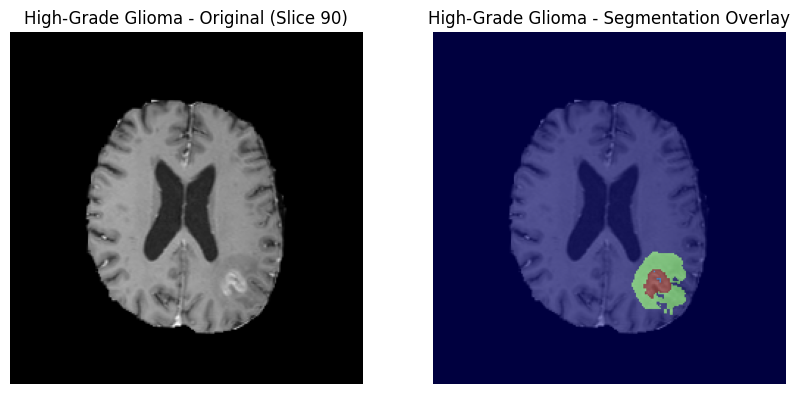

[Low-Grade Glioma] Max Tumor Area found at Slice Index: 58


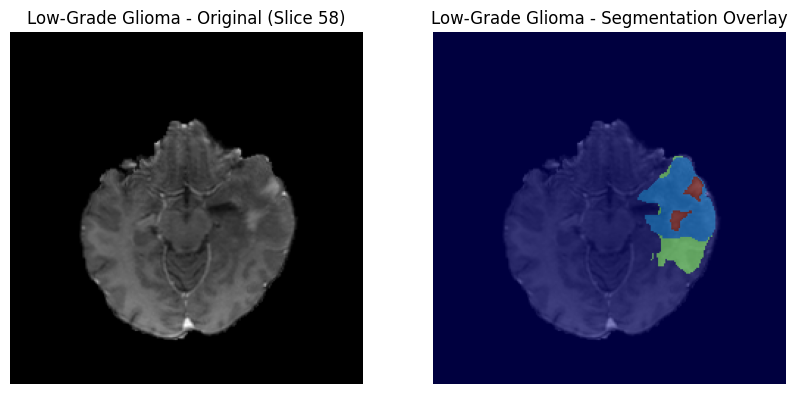

In [ ]:
import matplotlib.pyplot as plt # Added import

def visualize_lesion(image, mask, title=""):
    # SimpleITK 이미지를 numpy 배열로 변환
    img_arr = sitk.GetArrayFromImage(image)
    mask_arr = sitk.GetArrayFromImage(mask)

    # 종양(Mask) 영역이 가장 넓은 Slice(단면) 찾기
    # (종양이 없는 슬라이스를 보여주지 않도록 자동 탐색)
    mask_area_per_slice = np.sum(mask_arr, axis=(1, 2))
    z_max = np.argmax(mask_area_per_slice)

    print(f"[{title}] Max Tumor Area found at Slice Index: {z_max}")

    # 시각화 (Original vs Overlay)
    plt.figure(figsize=(10, 5))

    # 1. 원본 영상
    plt.subplot(1, 2, 1)
    plt.imshow(img_arr[z_max, :, :], cmap='gray')
    plt.title(f"{title} - Original (Slice {z_max})")
    plt.axis('off')

    # 2. 마스크 오버레이 (Lab 08 스타일: cmap='jet', alpha=0.5)
    plt.subplot(1, 2, 2)
    plt.imshow(img_arr[z_max, :, :], cmap='gray')
    plt.imshow(mask_arr[z_max, :, :], cmap='jet', alpha=0.5)
    plt.title(f"{title} - Segmentation Overlay")
    plt.axis('off')

    plt.show()

# Load images and masks within this cell for visualization
# This part is added to define img_h, mask_h, img_l, mask_l
img_h = sitk.ReadImage('H_t1ce.nii.gz')
mask_h = sitk.ReadImage('H_seg.nii.gz')
img_l = sitk.ReadImage('L_t1ce.nii.gz')
mask_l = sitk.ReadImage('L_seg.nii.gz')

# 시각화 실행
visualize_lesion(img_h, mask_h, "High-Grade Glioma")
visualize_lesion(img_l, mask_l, "Low-Grade Glioma")

In [ ]:
feature_names = [key for key in features_h.keys() if key.startswith("original_")]
data = []

for fname in feature_names:
    val_h = float(features_h[fname])
    val_l = float(features_l[fname])

    # 차이 비율 계산 (절대 차이 / 평균) -> 차이가 클수록 값이 큼
    diff_ratio = abs(val_h - val_l) / ((abs(val_h) + abs(val_l)) / 2 + 1e-6)

    data.append({
        "Feature_Name": fname,
        "H_Value": val_h,
        "L_Value": val_l,
        "Diff_Ratio": diff_ratio
    })

df = pd.DataFrame(data)

# 차이가 큰 순서대로 정렬하여 상위 10개 출력
df_sorted = df.sort_values(by='Diff_Ratio', ascending=False)

print("\n" + "="*50)
print("Top 10 Features with Largest Difference")
print("="*50)
display(df_sorted[['Feature_Name', 'H_Value', 'L_Value', 'Diff_Ratio']].head(10))


Top 10 Features with Largest Difference


,Feature_Name,H_Value,L_Value,Diff_Ratio
24,original_firstorder_Minimum,1.312956e+00,-0.302513,1.999998
28,original_firstorder_Skewness,-4.985426e-01,0.431617,1.999996
45,original_glcm_Imc1,0.000000e+00,-0.038157,1.999895
46,original_glcm_Imc2,0.000000e+00,0.003524,1.998866
50,original_glcm_JointEntropy,-3.203427e-16,0.001699,1.997648
54,original_glcm_SumEntropy,-3.203427e-16,0.001594,1.997494
39,original_glcm_DifferenceEntropy,-3.203427e-16,0.001537,1.997401
17,original_firstorder_Entropy,-3.203427e-16,0.001472,1.997286
33,original_glcm_ClusterProminence,0.000000e+00,0.000159,1.975150
8,original_shape_MeshVolume,3.462083e+02,50046.875000,1.972519


In [ ]:
## 2. Text cell

코드 실행 결과, 두 환자 간 가장 큰 차이를 보인 상위 5개 Feature는 다음과 같습니다.

| 순위 | Feature Class | Feature Name | H 환자 값 | L 환자 값 | 차이(Diff Ratio) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | First Order | **Minimum** | 1.31 | -0.30 | 약 2.00 |
| 2 | First Order | **Skewness** | -0.50 | 0.43 | 약 2.00 |
| 3 | GLCM | **Imc1** | 0.00 | -0.04 | 약 2.00 |
| 4 | GLCM | **Imc2** | 0.00 | 0.004 | 약 2.00 |
| 5 | GLCM | **JointEntropy** | 0.00 | 0.0017 | 약 2.00 |

*(참고: H 환자의 Entropy 관련 값들이 0에 가깝게 나온 것은 마스크 영역 내 픽셀 값들이 균일하거나 전처리 과정의 영향일 수 있습니다.)*

---

### **3. 주요 Feature 상세 분석**

#### **(1) First Order: Minimum (최솟값)**
* **값 비교:** H(1.31) > L(-0.30)
* **의미:** ROI(관심 영역) 내 가장 낮은 픽셀 강도입니다. H 환자의 최솟값이 더 높다는 것은 종양 영역 전체가 전반적으로 밝게 조영 증강되었음을 시사합니다.

#### **(2) First Order: Skewness (왜도)**
* **값 비교:** H(-0.50) vs L(0.43)
* **의미:** 값의 분포가 얼마나 비대칭인지를 나타냅니다.
    * **Negative Skew (H):** 밝은 픽셀이 더 많고 꼬리가 왼쪽(어두운 쪽)으로 긴 형태입니다. (강한 조영 증강)
    * **Positive Skew (L):** 어두운 픽셀이 더 많고 꼬리가 오른쪽(밝은 쪽)으로 긴 형태입니다.

#### **(3) GLCM: Imc1 (Information Measure of Correlation 1)**
* **의미:** 텍스처의 복잡성과 상관관계를 나타내는 척도입니다. 두 환자 간 텍스처 패턴의 규칙성에 큰 차이가 있음을 보여줍니다.

#### **(4) GLCM: Joint Entropy (결합 엔트로피)**
* **의미:** 이미지 내 픽셀 쌍의 무작위성(Randomness)을 나타냅니다. 일반적으로 값이 클수록 텍스처가 불규칙하고 복잡함을 의미합니다. 이번 결과에서는 L 환자가 미세하게 더 높은 값을 보였습니다.

#### **(5) Shape: MeshVolume (부피)** (순위 10번에 위치)
* **값 비교:** H(346.2) < L(50046.8)
* **의미:** 스크린샷 하단(8번 항목)을 보면 L 환자의 종양 부피가 H 환자보다 압도적으로 크게 측정되었습니다. 이는 L 환자의 종양 크기가 훨씬 큼을 의미합니다.

SyntaxError: invalid syntax (ipython-input-18-1549492781.py, line 3)